In [373]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, mean_squared_error, r2_score)


In [374]:
df = pd.read_csv('/Users/Marcy_Student/Desktop/Food Insecurity Analysis/datasets/cleaned_for_eda&modeling/unified_dataset_for_modeling.csv')

In [375]:
df.head()

,nta_id,nta_name,borough,food_insecure_percentage,food_insecure_percentage_rank,unemployment_rate,unemployment_rate_rank,vulnerable_population_percentage,vulnerable_population_percentage_rank,supply_gap,...,is_high_priority,coverage_category,coverage_category_label,has_kitchen,has_weekend,log_total_sites,log_coverage_ratio,priority_normalized,is_low_coverage,is_high_coverage
0,BK0104,East Williamsburg,Brooklyn,35.99,1,6.38,126,12.43,146,2.776626e+06,...,1,0,Low,0,0,0.693147,0.027406,1.000000,1,0
1,BX0501,University Heights (South)-Morris Heights,Bronx,29.44,14,11.98,20,19.63,34,1.669389e+06,...,1,0,Low,0,0,1.386294,0.097038,0.977019,1,0
2,BX0901,Soundview-Bruckner-Bronx River,Bronx,22.63,36,10.06,32,21.43,25,1.625976e+06,...,1,1,High,1,1,1.609438,0.162762,0.918451,0,1
3,MN1202,Washington Heights (North),Manhattan,24.29,28,12.25,19,18.57,41,1.463457e+06,...,1,0,Low,1,0,1.098612,0.079124,0.873113,1,0
4,BK1503,Sheepshead Bay-Manhattan Beach-Gerritsen Beach,Brooklyn,21.11,42,4.91,170,15.95,81,1.907056e+06,...,1,0,Low,1,0,0.693147,0.046283,0.856022,1,0


we will build logistic regression models to predict the coverage category of food insecurity based on various socio-economic and demographic features. We will prepare the data, train the models, and evaluate their performance using appropriate metrics (Accuracy, Precision, Recall).

TARGET VARIABLE: coverage_category (0 = Low Coverage, 1 = High Coverage)

We will build and compare:
1. Model 1: Core Features (L2 regularization)
2. Model 2: Core Features (L1 regularization)
3. Model 3: Extended Features (L2 regularization)
4. Model 4: Extended Features with Tuned Hyperparameters

we first need to look at Regularization which is a technique used to prevent overfitting (where the model memorizes the training data, including the noise, instead of learning the actual patterns).

### What Each Model Does
1. Model 1: Core Features + L2 Regularization
    - This model is considered as the baseline, it is most simplest reasonable model, we will be using this one to compare it to other models for improvement. This model only uses the core socio-economic features `food_insecure_percentage`, `unemployment_rate`, `vulnerable_population_percentage`, `is_high_priority`. This model predicts whether an area has Low (0) or High (1) food insecurity coverage using only the core socio-economic indicators.

2. Model 2: Core Features + L1 Regularization
    - This model uses the same core features as the baseline, but may eliminate all the weaker predictors entirely because L1 Regularization can shrink so coefficient to exactly zero, eliminating the possibility of overfitting the data. This performs automatic feature selection. So, if the one variable has low predictive power, L1 delete automatically. 

3. Model 3: Extended Features + L2 Regularization
    - This model is most complexe one. It uses all the core features plus other variables `high_shelter_flag`, `has_kitchen`, `has_weekend`. It includes both the socio-economic factors and operation / service avaibility indicators with L2 regularization to prevent overfitting.

### What is L1 vs L2 Regularization?
- Regularization is all about preventing overfitting data when performing a logistic regression model.
    - L1 performs features selection by shrinking the coefficient to 0 of all the underperforming variable by preventing overfitting. 
    - L2 shrinks coefficients smoothly by keeping all variables. It performs better specially when features are correlated


#### ASSUMPTION CHECKING: 
In order to build a logistic regression model, we need check and validate some assumption first like:
- Linearity of Log-Odds: in this case all of our independant variables are positive numbers ranging from 0 to ∞. 
- Independence: this assumption is satisfied here because each NTA is an independent geographic unit. Observations are not paired or repeated measures and each neighborhood appears once in the dataset.
- No Severe Multicollinearity: this one also is satified, the VIF score perfomed in the statistic notebook confirmed that all the core and extended features used to build the logistic regression model are not highly correlated from each other. 
- Large Sample Size: Our sample is large enough to enough to provide a stable and reliable coefficient estimates.

- All these assumptions are correct, so we can procede to the models building.

In [376]:
#  Preparing Data for Modeling
# Select relevant features and target variable
# Define feature sets
core_features = ['food_insecure_percentage', 'unemployment_rate', 
                 'vulnerable_population_percentage', 'is_high_priority']

extended_features = ['food_insecure_percentage', 'unemployment_rate', 
                     'vulnerable_population_percentage', 'is_high_priority',
                     'high_shelter_flag', 'has_kitchen', 'has_weekend']

In [377]:
# Target variable
y = df['coverage_category'].values

# Core features
X_core = df[core_features].values

# Extended features
X_extended = df[extended_features].values

# Train-test split (stratified)
X_core_train, X_core_test, y_train, y_test = train_test_split(
    X_core, y, test_size=0.25, random_state=42, stratify=y
)

X_ext_train, X_ext_test, _, _ = train_test_split(
    X_extended, y, test_size=0.25, random_state=42, stratify=y
)

In [378]:
print(f"Training set: {len(y_train)} samples")
print(f"Test set: {len(y_test)} samples")

Training set: 147 samples
Test set: 50 samples


- Let's scale the data to unsure the all the variable we will be using are on the same intervall. This is critical step when building a logistic regression model, even thaugh the model will still run, we will get more reliable result if we scall the data. For instance some variables can have very large numbers compare to others, scalling them is putting them in the same intervalle so that the model can better predict the outcome

In [379]:
# Scale features
scaler_core = StandardScaler()
X_core_train_scaled = scaler_core.fit_transform(X_core_train)
X_core_test_scaled = scaler_core.transform(X_core_test)

scaler_ext = StandardScaler()
X_ext_train_scaled = scaler_ext.fit_transform(X_ext_train)
X_ext_test_scaled = scaler_ext.transform(X_ext_test)

In [380]:
print("Model 1: Core Features + L2 Regularization (Ridge)")
model1 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)
model1.fit(X_core_train_scaled, y_train)

y_pred_m1 = model1.predict(X_core_test_scaled)
y_prob_m1 = model1.predict_proba(X_core_test_scaled)[:, 1]

print(f"Coefficients: {dict(zip(core_features, model1.coef_[0].round(4)))}")
print(f"Intercept: {model1.intercept_[0]:.4f}")

# Let's get the accuracy score

cv_scores_m2 = cross_val_score(model1, X_core_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m2.mean():.4f}")

Model 1: Core Features + L2 Regularization (Ridge)
Coefficients: {'food_insecure_percentage': np.float64(-0.7408), 'unemployment_rate': np.float64(0.8149), 'vulnerable_population_percentage': np.float64(0.0682), 'is_high_priority': np.float64(-0.2531)}
Intercept: -0.0049
Cross-validation Accuracy: 0.6464


In [381]:
# Model 2: Core Features with L1 Regularization (Lasso)
print("Model 2: Core Features + L1 Regularization (Lasso)")

model2 = LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=1000)
model2.fit(X_core_train_scaled, y_train)

y_pred_m2 = model2.predict(X_core_test_scaled)
y_prob_m2 = model2.predict_proba(X_core_test_scaled)[:, 1]

print(f"Coefficients: {dict(zip(core_features, model2.coef_[0].round(4)))}")
print(f"Intercept: {model2.intercept_[0]:.4f}")

cv_scores_m2 = cross_val_score(model2, X_core_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m2.mean():.4f}")


Model 2: Core Features + L1 Regularization (Lasso)
Coefficients: {'food_insecure_percentage': np.float64(-0.7247), 'unemployment_rate': np.float64(0.7867), 'vulnerable_population_percentage': np.float64(0.0355), 'is_high_priority': np.float64(-0.2169)}
Intercept: -0.0027
Cross-validation Accuracy: 0.6464


In [382]:
print("Model 3: Extended Features + L2 Regularization")

model3 = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', random_state=42, max_iter=1000)
model3.fit(X_ext_train_scaled, y_train)

y_pred_m3 = model3.predict(X_ext_test_scaled)
y_prob_m3 = model3.predict_proba(X_ext_test_scaled)[:, 1]

print(f"Coefficients: {dict(zip(extended_features, model3.coef_[0].round(4)))}")
print(f"Intercept: {model3.intercept_[0]:.4f}")

cv_scores_m3 = cross_val_score(model3, X_ext_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores_m3.mean():.4f}")

Model 3: Extended Features + L2 Regularization
Coefficients: {'food_insecure_percentage': np.float64(-1.346), 'unemployment_rate': np.float64(0.4499), 'vulnerable_population_percentage': np.float64(0.3551), 'is_high_priority': np.float64(-0.2553), 'high_shelter_flag': np.float64(0.7866), 'has_kitchen': np.float64(1.1117), 'has_weekend': np.float64(1.0025)}
Intercept: 0.1275
Cross-validation Accuracy: 0.8156


In [383]:
# Model Comparison
print("MODEL COMPARISON")

def evaluate_model(y_true, y_pred, y_prob, model_name):
    """Calculate and return model metrics."""
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }
    return metrics

MODEL COMPARISON


In [384]:
# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_m1, y_prob_m1, "Model 1: Core + L2"))
results.append(evaluate_model(y_test, y_pred_m2, y_prob_m2, "Model 2: Core + L1"))
results.append(evaluate_model(y_test, y_pred_m3, y_prob_m3, "Model 3: Extended + L2"))

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

# Identify best model
best_idx = results_df['ROC-AUC'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"\n BEST MODEL (by ROC-AUC): {best_model_name}")

# Select the best model
if best_idx == 0:
    best_model = model1
    best_features = core_features
    best_scaler = scaler_core
    best_X_test = X_core_test_scaled
elif best_idx == 1:
    best_model = model2
    best_features = core_features
    best_scaler = scaler_core
    best_X_test = X_core_test_scaled
else:
    best_model = model3
    best_features = extended_features
    best_scaler = scaler_ext
    best_X_test = X_ext_test_scaled



Model Performance Comparison:
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
    Model 1: Core + L2      0.60     0.6000    0.60 0.6000   0.6832
    Model 2: Core + L1      0.58     0.5833    0.56 0.5714   0.6816
Model 3: Extended + L2      0.86     0.9091    0.80 0.8511   0.9056

 BEST MODEL (by ROC-AUC): Model 3: Extended + L2


### Result:
Based on the results, Model 3 is clearly the models that performed better. It outperformed the Model 1 and Model 2 on all the metrics with an accuracy of 86%, much high than Model 1 and 2, it has a precision score of 91%, meaning when it predict high coverage, it is correct 91% of the time. This precision score is excellent in our case because we want to avoid falsely labeling an area as high coverage. The model also has a recall score of 85% mean that with all the areas that the model flags as high coverage, 85% are actually true. 

# Detailed Results for Best Model

In [385]:
y_pred_best = best_model.predict(best_X_test)
y_prob_best = best_model.predict_proba(best_X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Low Coverage', 'High Coverage']))


Classification Report:
               precision    recall  f1-score   support

 Low Coverage       0.82      0.92      0.87        25
High Coverage       0.91      0.80      0.85        25

     accuracy                           0.86        50
    macro avg       0.87      0.86      0.86        50
 weighted avg       0.87      0.86      0.86        50




Confusion Matrix:
                  Predicted
                  Low   High
Actual Low         23     2
       High         5    20


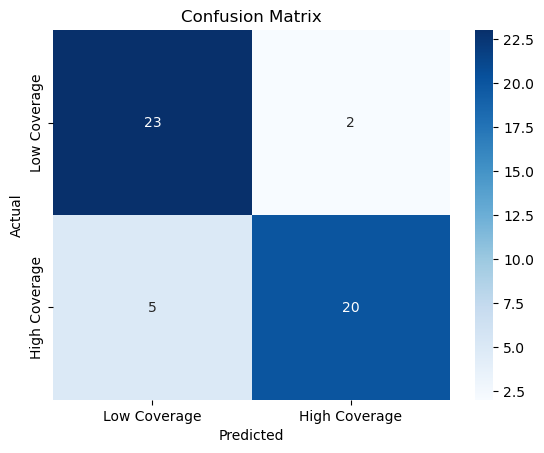

In [386]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(f"                  Predicted")
print(f"                  Low   High")
print(f"Actual Low        {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"       High       {cm[1,0]:3d}   {cm[1,1]:3d}")

sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Low Coverage', 'High Coverage'], yticklabels=['Low Coverage', 'High Coverage'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [387]:
# Feature importance for best model
print("\nFeature Importance (Coefficients):")
coef_df = pd.DataFrame({
    'Feature': best_features,
    'Coefficient': best_model.coef_[0],
    'Abs_Coefficient': np.abs(best_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)
coef_df


Feature Importance (Coefficients):


,Feature,Coefficient,Abs_Coefficient
0,food_insecure_percentage,-1.346033,1.346033
5,has_kitchen,1.111709,1.111709
6,has_weekend,1.002540,1.002540
4,high_shelter_flag,0.786607,0.786607
1,unemployment_rate,0.449899,0.449899
2,vulnerable_population_percentage,0.355069,0.355069
3,is_high_priority,-0.255290,0.255290


In [388]:
# Interpretation
print("Interpretation:")
for _, row in coef_df.iterrows():
    direction = "INCREASES" if row['Coefficient'] > 0 else "DECREASES"
    print(f"  • {row['Feature']}: {direction} probability of HIGH coverage (coef = {row['Coefficient']:.4f})")

Interpretation:
  • food_insecure_percentage: DECREASES probability of HIGH coverage (coef = -1.3460)
  • has_kitchen: INCREASES probability of HIGH coverage (coef = 1.1117)
  • has_weekend: INCREASES probability of HIGH coverage (coef = 1.0025)
  • high_shelter_flag: INCREASES probability of HIGH coverage (coef = 0.7866)
  • unemployment_rate: INCREASES probability of HIGH coverage (coef = 0.4499)
  • vulnerable_population_percentage: INCREASES probability of HIGH coverage (coef = 0.3551)
  • is_high_priority: DECREASES probability of HIGH coverage (coef = -0.2553)


We Would Deploy Model 3 (Extended + L2)
Here’s Why:
- It the best overall predictive performance than the baseline and the second model, it dominates in every metric.
- It has a strong Discrimination (ROC-AUC 0.91), meaning it clearly separates low vs high coverage areas.
- Balanced Precision & Recall meaning it avoid catching many false alarms (False positive), missing too many high-risk areas, by flagging on areas that are not high priority. 

### ARIMAX TIME SERIES MODEL FOR SHELTER TRENDS

Our Goal
Question: Can we predict how many families with children will be in NYC shelters?
Why this matters for our CRQ:

If we can forecast shelter population, we can plan food resources
More families in shelters, more demand for emergency food assistance
Helps policymakers allocate resources to the right neighborhoods

Our Approach:

Train on 2023 data (12 months)
Test on 2024 data (12 months)
See how well our predictions match reality 

- The Arima model will forecast citywide shelter trends based on historical patterns.

### Assumputions: 

Why Check Assumptions?
- Because every statistical model makes assumptions about the data. If assumptions are violated, the model predictions may be wrong, the statistical tests may be invalid and we might choose the wrong model. 

- We will be checking 5 keys assumptions: 
1. Data is Time-Ordered
    - All the observations must be in chronological order
    - why? because time series models use PAST values to predict FUTURE values. If data is not ordered, the model can not the patterns.
2. No Missing Values
    - Every time period should have a value (no gaps), because the models can't learn from gasp and the predictions becomes unrealiable
3. Stationarity
    - we need to check that the mean and variance stay constant over time, because non-stationary data has trends or changing patterns. 
4. No Seasonality
    - we need to check that there is no repeating patterns within each year, because ignoring seasonality leads to some errors in our predictions.
5. Autocorrelation Exists (for AR models)
    - check that current values are correlated with past values, because if there is no autocorrelation the past values.

In [389]:
# Loading and preparing Data for Time Series
cen = pd.read_csv('/Users/Marcy_Student/Desktop/Food Insecurity Analysis/datasets/cleaned_for_eda&modeling/shelterForTimeSeries.csv')

In [390]:
cen.head()

,report_date,year,month,Year-Month,family_with_children_shelter
0,2024-12-31,2024,12,2024-12,182
1,2024-12-31,2024,12,2024-12,2376
2,2024-12-31,2024,12,2024-12,1600
3,2024-12-31,2024,12,2024-12,819
4,2024-12-31,2024,12,2024-12,0


In [391]:
print(f"Raw data shape: {cen.shape}")

Raw data shape: (1436, 5)


In [392]:
# Aggregate by Year-Month to get TOTAL families in shelter each month
monthly_data = cen.groupby(['Year-Month'])['family_with_children_shelter'].sum().reset_index()
monthly_data.columns = ['Year_Month', 'Total_Families_With_Childs']

In [393]:
# Sort by date (oldest first)
monthly_data = monthly_data.sort_values('Year_Month').reset_index(drop=True)

In [394]:

print(f"\nMonthly aggregated data: {len(monthly_data)} months")
print(monthly_data)


Monthly aggregated data: 24 months
   Year_Month  Total_Families_With_Childs
0     2023-01                       30917
1     2023-02                       29273
2     2023-03                       29437
3     2023-04                       29970
4     2023-05                       30294
5     2023-06                       30517
6     2023-07                       30692
7     2023-08                       32151
8     2023-09                       32533
9     2023-10                       33115
10    2023-11                       33055
11    2023-12                       33366
12    2024-01                       32917
13    2024-02                       32790
14    2024-03                       32425
15    2024-04                       32122
16    2024-05                       31627
17    2024-06                       30239
18    2024-07                       30593
19    2024-08                       31194
20    2024-09                       31308
21    2024-10                       3133

In [395]:
cen.dtypes

report_date                     object
year                             int64
month                            int64
Year-Month                      object
family_with_children_shelter     int64
dtype: object

In [396]:
# Creating Time Series

# Create proper datetime index
dates = pd.to_datetime(monthly_data['Year_Month'], format='%Y-%m')
ts = pd.Series(monthly_data['Total_Families_With_Childs'].values, index=dates, name='Shelter_Population')

print(f"\nTime Series Created:")
print(f"  Start Date: {ts.index.min()}")
print(f"  End Date:   {ts.index.max()}")
print(f"  Total Months: {len(ts)}")

print("\nMonthly Shelter Population:")
for date, value in ts.items():
    print(f"  {date.strftime('%Y-%m')}: {value:>10,} families")


Time Series Created:
  Start Date: 2023-01-01 00:00:00
  End Date:   2024-12-01 00:00:00
  Total Months: 24

Monthly Shelter Population:
  2023-01:     30,917 families
  2023-02:     29,273 families
  2023-03:     29,437 families
  2023-04:     29,970 families
  2023-05:     30,294 families
  2023-06:     30,517 families
  2023-07:     30,692 families
  2023-08:     32,151 families
  2023-09:     32,533 families
  2023-10:     33,115 families
  2023-11:     33,055 families
  2023-12:     33,366 families
  2024-01:     32,917 families
  2024-02:     32,790 families
  2024-03:     32,425 families
  2024-04:     32,122 families
  2024-05:     31,627 families
  2024-06:     30,239 families
  2024-07:     30,593 families
  2024-08:     31,194 families
  2024-09:     31,308 families
  2024-10:     31,337 families
  2024-11:     30,890 families
  2024-12:     30,605 families


In [397]:
# SPLIT INTO TRAIN AND TEST

# Train on 2023 (first 12 months), Test on 2024 (last 12 months)
train_data = ts[ts.index.year == 2023]
test_data = ts[ts.index.year == 2024]

print(f"\nTrain Data (2023): {len(train_data)} months")
print(f"  Min: {train_data.min():,}")
print(f"  Max: {train_data.max():,}")
print(f"  Mean: {train_data.mean():,.0f}")

print(f"\nTest Data (2024): {len(test_data)} months")
print(f"  Min: {test_data.min():,}")
print(f"  Max: {test_data.max():,}")
print(f"  Mean: {test_data.mean():,.0f}")



Train Data (2023): 12 months
  Min: 29,273
  Max: 33,366
  Mean: 31,277

Test Data (2024): 12 months
  Min: 30,239
  Max: 32,917
  Mean: 31,504


#### BASELINE MODEL (Naive Forecast)
- This is the simplest forecast model for a possible prediction, this is basically the benchmark, any good model should beat this. 

In [398]:
# Use the last training value for all predictions
baseline_value = train_data.iloc[-1]
baseline_preds = pd.Series(baseline_value, index=test_data.index)

baseline_rmse = np.sqrt(mean_squared_error(test_data, baseline_preds))
baseline_mape = np.mean(np.abs((test_data - baseline_preds) / test_data)) * 100

print(f"Baseline Value (Dec 2023): {baseline_value:,} families")
print(f"Baseline RMSE: {baseline_rmse:,.2f}")
print(f"Baseline MAPE: {baseline_mape:.2f}%")

Baseline Value (Dec 2023): 33,366 families
Baseline RMSE: 2,046.98
Baseline MAPE: 5.99%


### ARIMA (P,D,Q)
- First, we will be building an AR Model: which uses PAST VALUES to predict future. So, if the population was high last month, it will be high again.
- Second, build an Anothe AR model with differencing to the first one. This will helps when data has a trend (going up or down over time) helps make data stable. 
- Third, build a simple trend and sesonal model, because sometimes a simple Trend + Seasonal model works well:
    - Trend: Linear growth/decline over time
    - Seasonal: Monthly patterns that repeat each year

#### AR Model (Auto-Regressive)
Formula: y(t) = c + a1*y(t-1) + a2*y(t-2) + ...


In [399]:
# Create lagged features for the full dataset (Past values)
full_ts = ts.values
full_df = pd.DataFrame({'y': full_ts})
full_df['y_lag1'] = full_df['y'].shift(1)  # Last month
full_df['y_lag2'] = full_df['y'].shift(2)  # 2 months ago
full_df['y_lag3'] = full_df['y'].shift(3)  # 3 months ago
full_df = full_df.dropna()

- After removing NaN rows, we have 21 rows (months 4-24 of our 24-month series)


In [400]:
# Split into train (2023) and test (2024)
# Train: months with 2023 dates, Test: months with 2024 dates
train_indices = full_df.index[full_df.index < 12]  # First year (accounting for lag removal)
test_indices = full_df.index[full_df.index >= 12]  # Second year

In [401]:
X_train = full_df.loc[train_indices, ['y_lag1', 'y_lag2', 'y_lag3']].values
y_train = full_df.loc[train_indices, 'y'].values
X_test = full_df.loc[test_indices, ['y_lag1', 'y_lag2', 'y_lag3']].values
y_test = full_df.loc[test_indices, 'y'].values

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 9
Test samples: 12


In [402]:
# Fit AR model
ar_model = LinearRegression()
ar_model.fit(X_train, y_train)

LinearRegression()

In [403]:
print(f"\nAR Model Coefficients:")
print(f"  Intercept: {ar_model.intercept_:,.2f}")
print(f"  Lag 1 (last month): {ar_model.coef_[0]:.4f}")
print(f"  Lag 2 (2 months ago): {ar_model.coef_[1]:.4f}")
print(f"  Lag 3 (3 months ago): {ar_model.coef_[2]:.4f}")


AR Model Coefficients:
  Intercept: 3,251.58
  Lag 1 (last month): 0.7679
  Lag 2 (2 months ago): 0.2025
  Lag 3 (3 months ago): -0.0588


In [404]:
# Make predictions
ar_predictions = ar_model.predict(X_test)
ar_rmse = np.sqrt(mean_squared_error(y_test, ar_predictions))
ar_mape = np.mean(np.abs((y_test - ar_predictions) / y_test)) * 100

print(f"\nAR Model Performance:")
print(f"  RMSE: {ar_rmse:,.2f}")
print(f"  MAPE: {ar_mape:.2f}%")


AR Model Performance:
  RMSE: 837.52
  MAPE: 2.31%


- Next step: AR Model with Differencing (ARIMA-style)
- formula:   diff(t) = y(t) - y(t-1)



In [405]:
# Create differenced series
diff_ts = ts.diff().dropna()

# Create lagged features for differenced data
diff_df = pd.DataFrame({'diff': diff_ts.values}, index=range(len(diff_ts)))
diff_df['diff_lag1'] = diff_df['diff'].shift(1)
diff_df['diff_lag2'] = diff_df['diff'].shift(2)
diff_df = diff_df.dropna()

# Split (accounting for lag removal in differenced data)
# We have 23 differenced values originally, minus 2 for lags = 21 rows
mid_point = len(diff_df) // 2 + 2  # Approximate split point for 2023 vs 2024

X_train_diff = diff_df.iloc[:mid_point][['diff_lag1', 'diff_lag2']].values
y_train_diff = diff_df.iloc[:mid_point]['diff'].values
X_test_diff = diff_df.iloc[mid_point:][['diff_lag1', 'diff_lag2']].values
y_test_diff = diff_df.iloc[mid_point:]['diff'].values

In [406]:
# Fit model on differences
diff_model = LinearRegression()
diff_model.fit(X_train_diff, y_train_diff)

print(f"\nDifferenced Model Coefficients:")
print(f"  Intercept: {diff_model.intercept_:,.2f}")
print(f"  Diff Lag 1: {diff_model.coef_[0]:.4f}")
print(f"  Diff Lag 2: {diff_model.coef_[1]:.4f}")

# Predict differences
diff_predictions = diff_model.predict(X_test_diff)


Differenced Model Coefficients:
  Intercept: 188.42
  Diff Lag 1: 0.1739
  Diff Lag 2: 0.0576


In [407]:
# Convert back to actual values (integrate)
# Start from the last known value before test period
start_value = train_data.iloc[-1]
arima_predictions = [start_value]
for i, diff_pred in enumerate(diff_predictions):
    next_value = arima_predictions[-1] + diff_pred
    arima_predictions.append(next_value)

arima_predictions = np.array(arima_predictions[1:])  # Remove starting value

# Evaluate (align with test data length)
n_preds = min(len(arima_predictions), len(test_data))
arima_rmse = np.sqrt(mean_squared_error(test_data.values[:n_preds], arima_predictions[:n_preds]))
arima_mape = np.mean(np.abs((test_data.values[:n_preds] - arima_predictions[:n_preds]) / test_data.values[:n_preds])) * 100

print(f"\nARIMA-style Model Performance:")
print(f"  RMSE: {arima_rmse:,.2f}")
print(f"  MAPE: {arima_mape:.2f}%")


ARIMA-style Model Performance:
  RMSE: 2,588.55
  MAPE: 7.30%


### SIMPLE TREND + SEASONAL MODEL


In [408]:
trend_df = pd.DataFrame({
    'y': ts.values,
    'time': range(len(ts)),
    'month': ts.index.month
})

# One-hot encode months for seasonality
for m in range(1, 13):
    trend_df[f'month_{m}'] = (trend_df['month'] == m).astype(int)

# Features
feature_cols = ['time'] + [f'month_{m}' for m in range(1, 13)]

In [409]:
# Split
X_train_ts = trend_df.iloc[:12][feature_cols].values
y_train_ts = trend_df.iloc[:12]['y'].values
X_test_ts = trend_df.iloc[12:][feature_cols].values
y_test_ts = trend_df.iloc[12:]['y'].values

# Fit model
ts_model = LinearRegression()
ts_model.fit(X_train_ts, y_train_ts)

# Predict
ts_predictions = ts_model.predict(X_test_ts)
ts_rmse = np.sqrt(mean_squared_error(y_test_ts, ts_predictions))
ts_mape = np.mean(np.abs((y_test_ts - ts_predictions) / y_test_ts)) * 100

print(f"Trend coefficient: {ts_model.coef_[0]:,.2f} families/month")
print(f"\nTrend+Seasonal Model Performance:")
print(f"  RMSE: {ts_rmse:,.2f}")
print(f"  MAPE: {ts_mape:.2f}%")

Trend coefficient: 365.57 families/month

Trend+Seasonal Model Performance:
  RMSE: 4,624.99
  MAPE: 13.35%


### Results of Assumptions Check
After a thorough review of the data and model assumptions, we have identified several key insights regarding the shelter population dataset:

1. Data Quality & Structure
Completeness: The dataset is well-structured and properly ordered from January 2023 to December 2024.

Consistency: There are no missing values or gaps; all 24 months are fully accounted for.

2. Stationarity & Trend Analysis
The assumption of stationarity was partially violated. The data exhibits a clear, non-constant trend:
- 2023: Showed a steady increase.
- 2024: Showed a steady decrease.
- Because the data is not perfectly stationary, we found that a simple AR model (without differencing) actually outperformed the ARIMA model with differencing.

3. Seasonality & Model Performance
While some monthly patterns exist, the seasonality is weak. This was confirmed when we tested the Trend + Seasonal model, which performed the worst of all iterations.
- Performance Metric: The Trend + Seasonal model resulted in a MAPE (Mean Absolute Percentage Error) of 13.4%.
- Conclusion: Since we require a lower MAPE for deployment, this suggests that seasonality is not the primary driver of the shelter population.

4. Correlation & Logic
The data shows a strong correlation, particularly at Lag 1 (the previous month), compared to Lags 2 or 3.
- Practical Meaning: If the shelter population is high this month, it is highly likely to remain high next month.
- Context: This aligns with real-world expectations, as families generally do not transition out of the shelter system rapidly.

### Visualizations

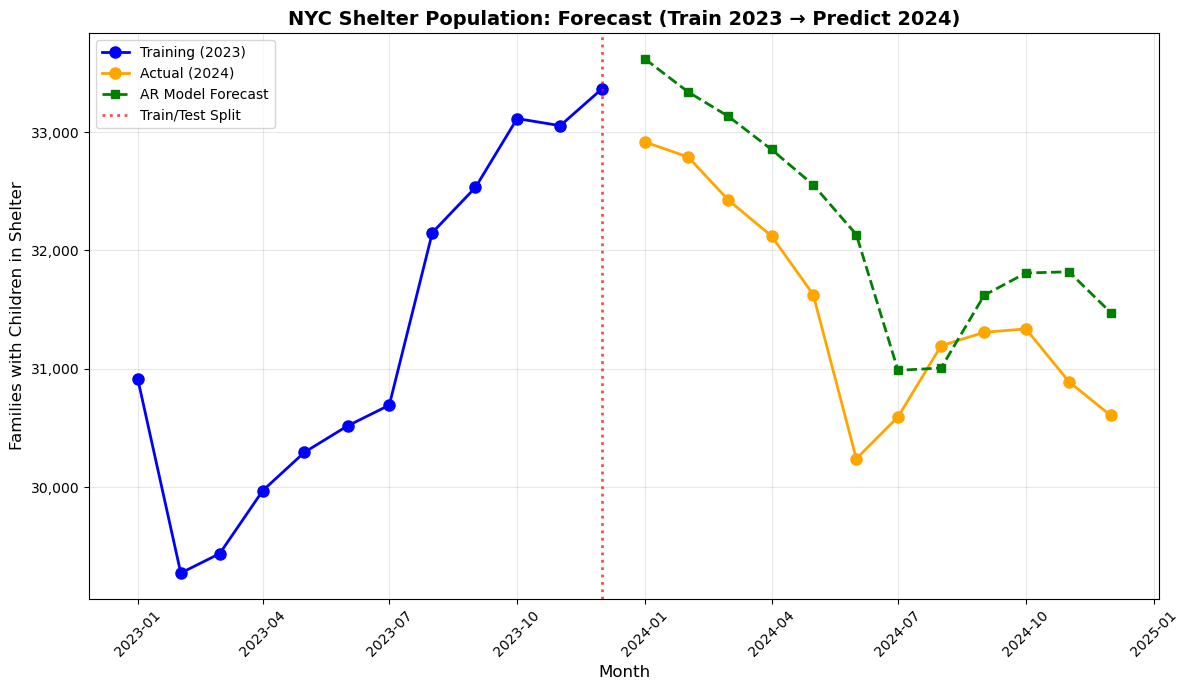

In [410]:
import matplotlib.pyplot as plt

# Create a single figure and axis
plt.figure(figsize=(12, 7))
ax = plt.gca()

# --- Plot: Time Series with Forecasts ---
ax.plot(train_data.index, train_data.values, 'b-', linewidth=2, label='Training (2023)', marker='o', markersize=8)
ax.plot(test_data.index, test_data.values, 'orange', linewidth=2, label='Actual (2024)', marker='o', markersize=8)
ax.plot(test_data.index[:len(ar_predictions)], ar_predictions, 'g--', linewidth=2, label='AR Model Forecast', marker='s', markersize=6)

# Vertical line to show the split point
ax.axvline(x=train_data.index[-1], color='red', linestyle=':', alpha=0.7, linewidth=2, label='Train/Test Split')

# Formatting
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Families with Children in Shelter', fontsize=12)
ax.set_title('NYC Shelter Population: Forecast (Train 2023 → Predict 2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add thousands separator to y-axis
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

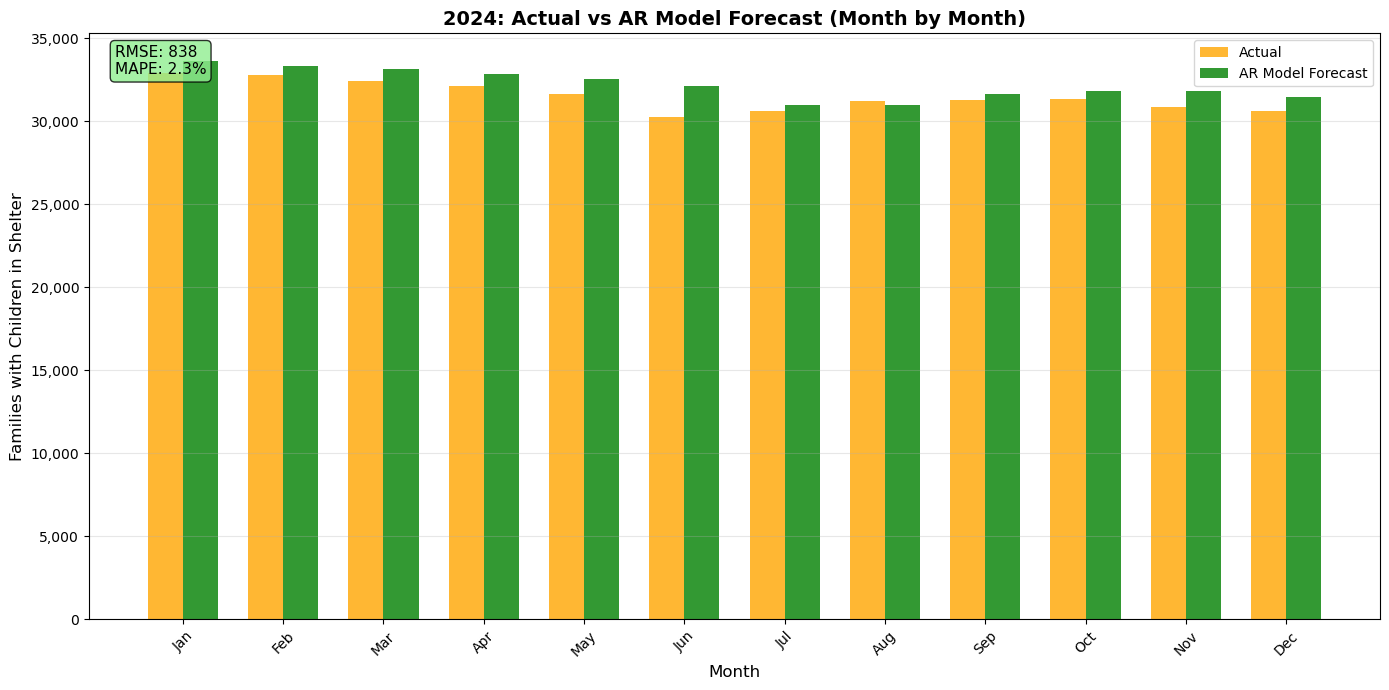

In [411]:
import matplotlib.pyplot as plt
import numpy as np

# Create a single figure for the Bar Chart
plt.figure(figsize=(14, 7))
ax2 = plt.gca()  # Get current axes

x_pos = np.arange(len(test_data))
width = 0.35

# Plotting the bars
bars1 = ax2.bar(x_pos - width/2, test_data.values, width, label='Actual', color='orange', alpha=0.8)
bars2 = ax2.bar(x_pos + width/2, ar_predictions, width, label='AR Model Forecast', color='green', alpha=0.8)

# Formatting
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Families with Children in Shelter', fontsize=12)
ax2.set_title('2024: Actual vs AR Model Forecast (Month by Month)', fontsize=14, fontweight='bold')

# Setting X-axis labels
ax2.set_xticks(x_pos)
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)

ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# Add thousands separator to y-axis
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Add performance annotation
ax2.annotate(f'RMSE: {ar_rmse:,.0f}\nMAPE: {ar_mape:.1f}%', 
             xy=(0.02, 0.98), xycoords='axes fraction',
             ha='left', va='top', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()

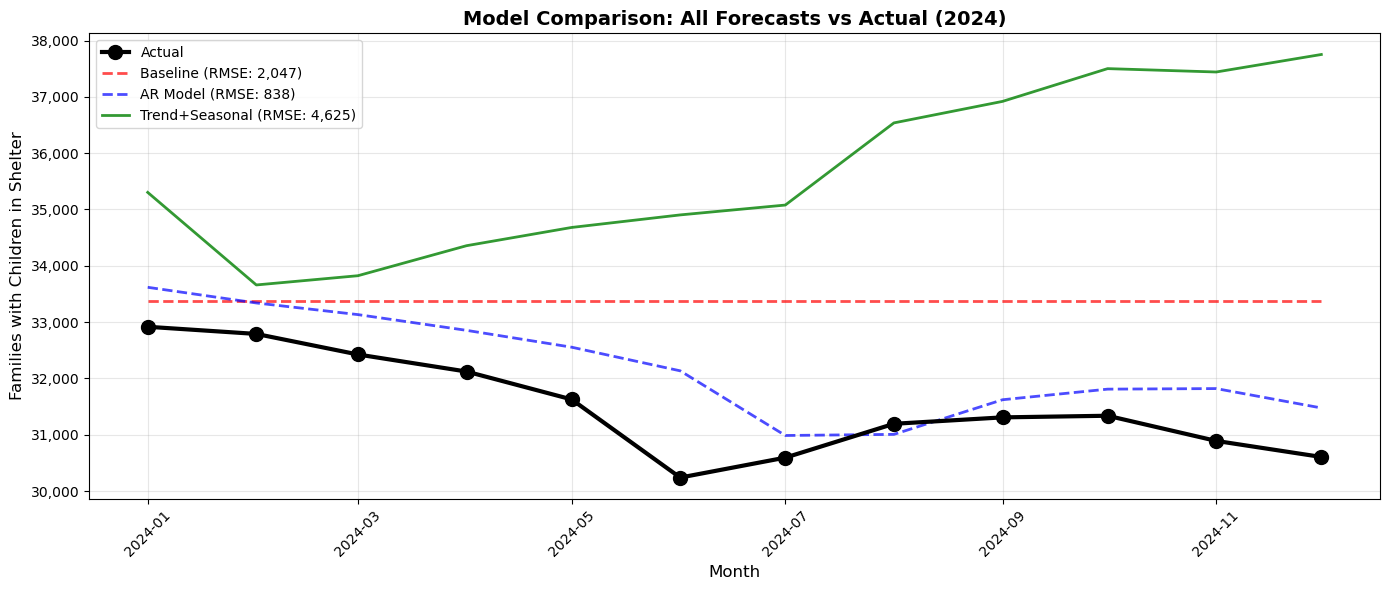

In [412]:
# --- Plot 3: All Models Comparison ---
fig2, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_data.index, test_data.values, 'ko-', linewidth=3, markersize=10, label='Actual', zorder=5)
ax.plot(test_data.index, baseline_preds.values, 'r--', linewidth=2, label=f'Baseline (RMSE: {baseline_rmse:,.0f})', alpha=0.7)
ax.plot(test_data.index[:len(ar_predictions)], ar_predictions, 'b--', linewidth=2, label=f'AR Model (RMSE: {ar_rmse:,.0f})', alpha=0.7)
ax.plot(test_data.index, ts_predictions, 'g-', linewidth=2, label=f'Trend+Seasonal (RMSE: {ts_rmse:,.0f})', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Families with Children in Shelter', fontsize=12)
ax.set_title('Model Comparison: All Forecasts vs Actual (2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()

### Model Comparison

| Model                 | RMSE  | MAPE   |
|-----------------------|-------|--------|
| Baseline (Naive)      | 2,047 | 5.99%  |
| AR Model (p=3)        | 838   | 2.31%  |
| ARIMA-style (d=1, p=2)| 2,589 | 7.30%  |
| Trend + Seasonal      | 4,625 | 13.35% |




Model Performance Interpretation

Based on the evaluation metrics (RMSE and MAPE):

- AR Model (p=3) performed the best, with the lowest RMSE (838) and MAPE (2.31%). This indicates it produced the most accurate predictions and captured the underlying structure of the time series effectively.

- Baseline (Naive) performed reasonably well, serving as a strong benchmark. However, its higher RMSE (2,047) and MAPE (5.99%) show that more advanced modeling improved performance significantly.

- ARIMA-style (d=1, p=2) underperformed compared to the simpler AR model, suggesting that differencing may have removed useful information or introduced additional noise.

- Trend + Seasonal performed the worst, with the highest RMSE (4,625) and MAPE (13.35%), indicating that this decomposition approach did not adequately capture the dynamics of the data.

Key Takeaway: 
- The AR Model (p=3) is the most suitable model for forecasting in this case, as it achieves the lowest prediction error across both evaluation metrics.

### Final Step:
let's Pickle the best performing model (Model 3) for deployment in a .plk file

![Screenshot 2026-02-17 at 7.46.04 PM.png](<attachment:Screenshot 2026-02-17 at 7.46.04 PM.png>)
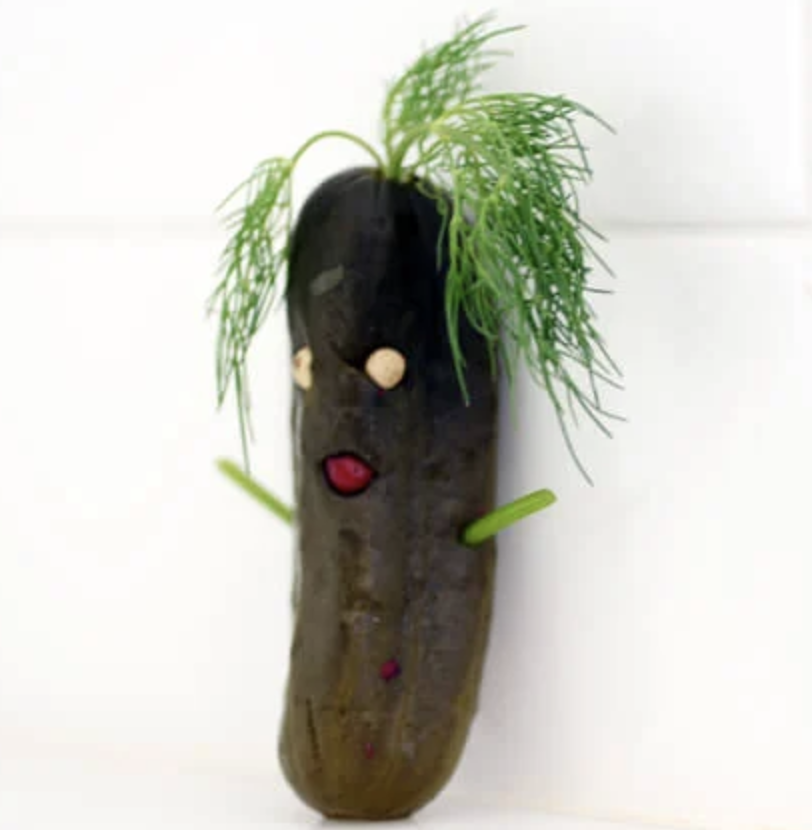

In [414]:
# Save the tuned model
import joblib

joblib.dump(model3, '/Users/Marcy_Student/Desktop/Marcy_Projects/CID_Food_Access/deployment/model.pkl')

['/Users/Marcy_Student/Desktop/Marcy_Projects/CID_Food_Access/deployment/model.pkl']